# Autoencoders

This notebook contains two example autoencoders, the first trained on MNIST and the second trained on CIFAR-10.  An autoencoder is neural network consisting of two parts: an encoder and a decoder.  As can be seen in the image below, the encoder compresses a given input to code.  This code part of the network is often called the bottleneck.  The decoder takes this code and produces an output.  

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png" width=500>

The output should be the same as the input and is leart using mean squared error loss:

$$ \mathcal{L} = \| input - output \|^2 $$

Since the bottleneck has a lower dimensionality than the input or output, the learning process forces the network to compress our input in a way that losses a little information as possible.  The more information that is retrained during the encoding, the better our output will be.

# MNIST

## Setup

Import python libraries

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

Are we using a GPU or a CPU?

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset

We will use the MNIST dataset which contains 10,000s of $28 \times 28$ resolution images.

In [10]:
# Load MNIST dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 64
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True)

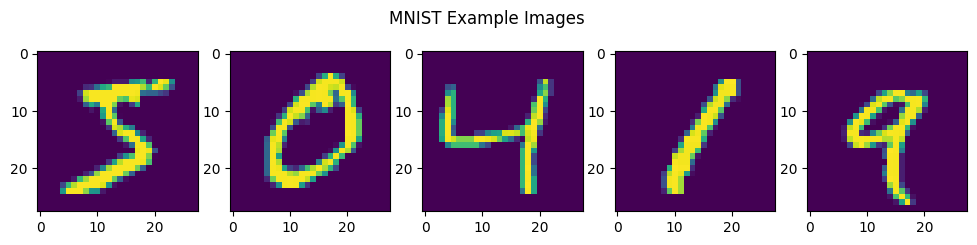

In [11]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
ax[0].imshow(mnist_dataset[0][0][0,:,:].numpy())
ax[1].imshow(mnist_dataset[1][0][0,:,:].numpy())
ax[2].imshow(mnist_dataset[2][0][0,:,:].numpy())
ax[3].imshow(mnist_dataset[3][0][0,:,:].numpy())
ax[4].imshow(mnist_dataset[4][0][0,:,:].numpy())


## Neural Network



We will be using a simple AutoEncoder here.  This network uses a combination of linear and convolution layers to compress an image into a smaller respresentation, then uses a decoder to network to reconstruct the image from this compressed representation.

In [12]:
class Autoencoder(nn.Module):
    def __init__(self, in_channels, img_size, latent_dim=128):
        super(Autoencoder, self).__init__()

        # What is the dimension of our image after going through the encoder?
        downsampled_size = int(img_size / 4)

        # Encoder
        self.encoder = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14

            # Second conv block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 7x7

            # Flatten and dense layers
            nn.Flatten(),
            nn.Linear(64 * downsampled_size * downsampled_size, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Dense layers
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 64 * downsampled_size * downsampled_size),
            nn.ReLU(),

            # Reshape layer
            nn.Unflatten(1, (64, downsampled_size, downsampled_size)),

            # First conv transpose block
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),  # 14x14
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            # Second conv transpose block
            nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


## Training

Train our autoencoder to reconstruct MNIST images.

In [13]:
def train_autoencoder(model, dataloader, epochs, learning_rate):

    # Initialize loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0
        for data in dataloader:
            # Sample data from dataset
            img, _ = data
            img = img.to(device)

            # Forward pass
            output = model(img)
            loss = criterion(output, img)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Log the loss for this epoch
        avg_loss = total_loss/len(dataloader)
        loss_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

    return model, loss_history

In [14]:
# Hyperparameters
epochs=20
learning_rate=1e-4

# Initialize model
img_size = 28
in_channels = 1
bottleneck_size = 32
mnist_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
mnist_model, loss_history = train_autoencoder(mnist_model, mnist_loader, epochs, learning_rate)

Epoch [1/20], Loss: 0.069313
Epoch [2/20], Loss: 0.021603
Epoch [3/20], Loss: 0.012839
Epoch [4/20], Loss: 0.009945
Epoch [5/20], Loss: 0.008496
Epoch [6/20], Loss: 0.007511
Epoch [7/20], Loss: 0.006783
Epoch [8/20], Loss: 0.006247
Epoch [9/20], Loss: 0.005821
Epoch [10/20], Loss: 0.005483
Epoch [11/20], Loss: 0.005193
Epoch [12/20], Loss: 0.004946
Epoch [13/20], Loss: 0.004726
Epoch [14/20], Loss: 0.004533
Epoch [15/20], Loss: 0.004369
Epoch [16/20], Loss: 0.004212
Epoch [17/20], Loss: 0.004083
Epoch [18/20], Loss: 0.003958
Epoch [19/20], Loss: 0.003852
Epoch [20/20], Loss: 0.003747


Text(0.5, 1.0, 'MNIST Training Loss')

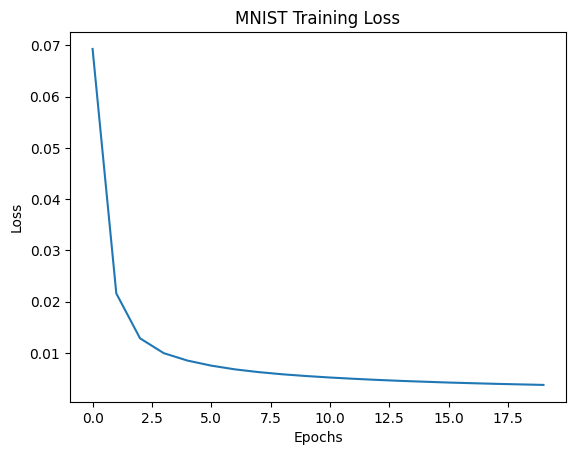

In [15]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MNIST Training Loss')

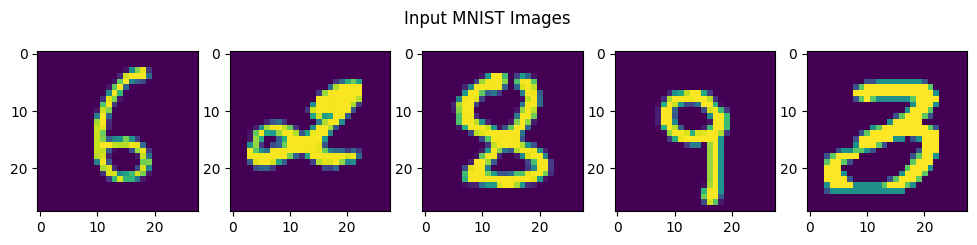

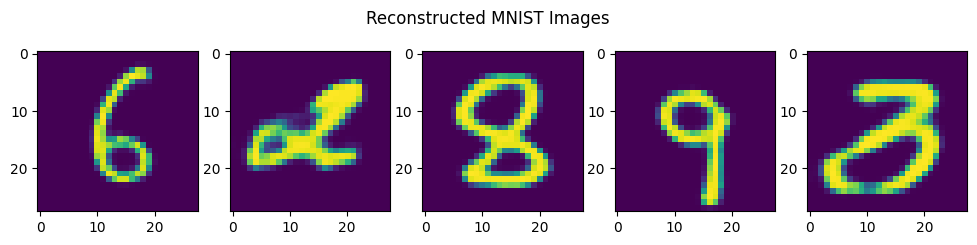

In [16]:
# Sample images
img, _ = next(iter(mnist_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input MNIST Images')
ax[0].imshow(img[0,0,:,:].cpu().numpy())
ax[1].imshow(img[1,0,:,:].cpu().numpy())
ax[2].imshow(img[2,0,:,:].cpu().numpy())
ax[3].imshow(img[3,0,:,:].cpu().numpy())
ax[4].imshow(img[4,0,:,:].cpu().numpy())
plt.show()

# Run images though the autoencdoer
output = mnist_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images')
ax[0].imshow(output[0,0,:,:].detach().cpu().numpy())
ax[1].imshow(output[1,0,:,:].detach().cpu().numpy())
ax[2].imshow(output[2,0,:,:].detach().cpu().numpy())
ax[3].imshow(output[3,0,:,:].detach().cpu().numpy())
ax[4].imshow(output[4,0,:,:].detach().cpu().numpy())
plt.show()

# CIFAR-10

## Dataset

Our second dataset the CIFAR-10 dataset.

In [17]:
# Load CIFAR-10 dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 64
cifar_dataset = datasets.CIFAR10(
    root='./data',  # Data will be downloaded to this directory
    train=True,     # Specify that we want the training dataset
    download=True,  # Download the dataset if it's not already downloaded
    transform=transform
)
cifar_loader = DataLoader(cifar_dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


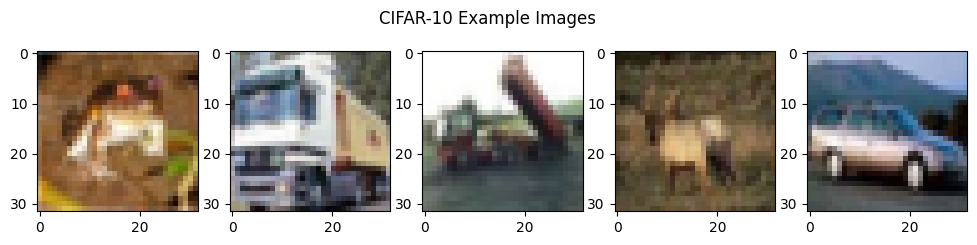

In [18]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('CIFAR-10 Example Images')
ax[0].imshow(np.transpose(cifar_dataset[0][0].numpy(), (1,2,0)))
ax[1].imshow(np.transpose(cifar_dataset[1][0].numpy(), (1,2,0)))
ax[2].imshow(np.transpose(cifar_dataset[2][0].numpy(), (1,2,0)))
ax[3].imshow(np.transpose(cifar_dataset[3][0].numpy(), (1,2,0)))
ax[4].imshow(np.transpose(cifar_dataset[4][0].numpy(), (1,2,0)))


## Training

Now we will train another autoencoder on the CIFAR-10 dataset.

In [19]:
# Initialize model, loss, and optimizer
img_size = 32
in_channels = 3
cifar_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
cifar_model, loss_history = train_autoencoder(cifar_model, cifar_loader, epochs, learning_rate)

Epoch [1/20], Loss: 0.037438
Epoch [2/20], Loss: 0.021124
Epoch [3/20], Loss: 0.017765
Epoch [4/20], Loss: 0.016023
Epoch [5/20], Loss: 0.014745
Epoch [6/20], Loss: 0.013758
Epoch [7/20], Loss: 0.013263
Epoch [8/20], Loss: 0.013008
Epoch [9/20], Loss: 0.012770
Epoch [10/20], Loss: 0.012641
Epoch [11/20], Loss: 0.012558
Epoch [12/20], Loss: 0.012512
Epoch [13/20], Loss: 0.012453
Epoch [14/20], Loss: 0.012407
Epoch [15/20], Loss: 0.012364
Epoch [16/20], Loss: 0.012324
Epoch [17/20], Loss: 0.012295
Epoch [18/20], Loss: 0.012262
Epoch [19/20], Loss: 0.012239
Epoch [20/20], Loss: 0.012206


Text(0.5, 1.0, 'CIFAR-10 Training Loss')

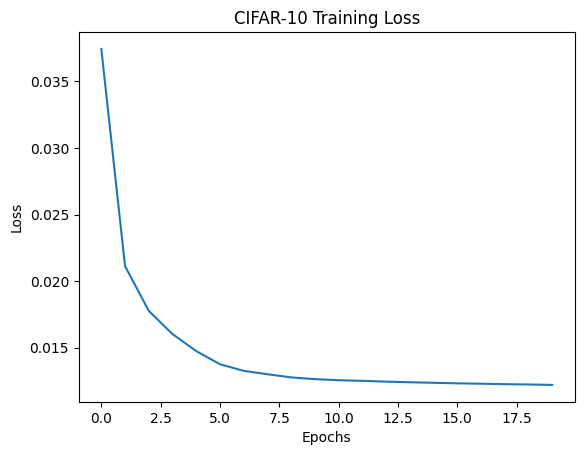

In [20]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-10 Training Loss')

Here we plot input images, and the image reconstructed by the autoencoder.  Since CIFAR-10 is a more complexe dataset than MNIST, results will be blurrier.

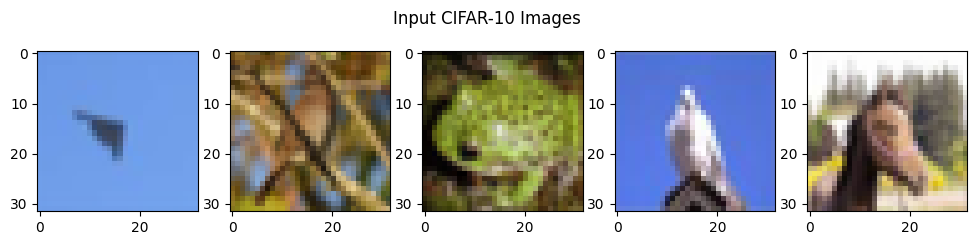

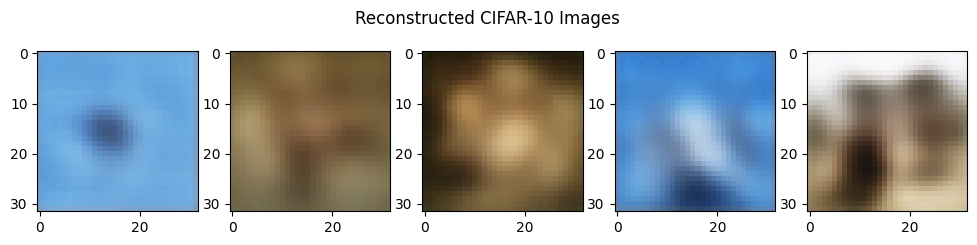

In [21]:
# Sample cifar-10 images
img, _ = next(iter(cifar_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input CIFAR-10 Images')
ax[0].imshow(np.transpose(img[0].cpu().numpy(), (1,2,0)))
ax[1].imshow(np.transpose(img[1].cpu().numpy(), (1,2,0)))
ax[2].imshow(np.transpose(img[2].cpu().numpy(), (1,2,0)))
ax[3].imshow(np.transpose(img[3].cpu().numpy(), (1,2,0)))
ax[4].imshow(np.transpose(img[4].cpu().numpy(), (1,2,0)))
plt.show()

# Run images though the autoencdoer
output = cifar_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed CIFAR-10 Images')
ax[0].imshow(np.transpose(output[0].detach().cpu().numpy(), (1,2,0)))
ax[1].imshow(np.transpose(output[1].detach().cpu().numpy(), (1,2,0)))
ax[2].imshow(np.transpose(output[2].detach().cpu().numpy(), (1,2,0)))
ax[3].imshow(np.transpose(output[3].detach().cpu().numpy(), (1,2,0)))
ax[4].imshow(np.transpose(output[4].detach().cpu().numpy(), (1,2,0)))
plt.show()

# Stitching

## Neural Network

Define a stitch which is a simple 1d convolution layer which will connect two sub-networks

In [42]:
class Stitch(nn.Module):

    def __init__(self, n_dims):
        super(Stitch, self).__init__()
        #self.bn1 = nn.BatchNorm2d(n_dims)
        self.conv = nn.Conv2d(n_dims, n_dims, kernel_size=1, stride=1, padding=0)
        #self.bn2 = nn.BatchNorm2d(n_dims)

    def forward(self, x):
        #out = self.bn1(x)
        out = self.conv(x)
        #out = self.bn2(out)   
        return out

In [43]:
class StichedAutoencoder(nn.Module):

    def __init__(self, encoder, decoder, bottleneck_size):
        super(StichedAutoencoder, self).__init__()
        self.bottleneck_size = bottleneck_size
        self.encoder = encoder
        self.stitch = Stitch(self.bottleneck_size)
        self.decoder = decoder

    def forward(self, x):
        x = self.encoder(x).view(-1,self.bottleneck_size,1,1)
        x = self.stitch(x).view(-1,self.bottleneck_size)
        x = self.decoder(x)
        return x
    
cifar_to_mnist_model = StichedAutoencoder(cifar_model.encoder, mnist_model.decoder, bottleneck_size).to(device)

# Put top model into train mode so that bn and dropout perform in training mode
cifar_to_mnist_model.train()
# Freeze the top model
cifar_to_mnist_model.requires_grad_(False)
# Un-Freeze the stitch layer
for name, param in cifar_to_mnist_model.stitch.named_parameters():
    param.requires_grad_(True)

## Dataset 

For training the stitch we will match CIFAR-10 to MNIST images in a one-to-one fashion.  Classes should also match up.  For instance, images of airplanes in CIFAR-10 should always be mapped images of 0's in MNIST.

In [44]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import numpy as np

class MNISTCIFARDataset(Dataset):
    def __init__(self, mnist_root='./data', cifar_root='./data', train=True):
        # Load datasets
        self.mnist = datasets.MNIST(root=mnist_root, train=train, download=True,
                                  transform=transforms.ToTensor())
        self.cifar = datasets.CIFAR10(root=cifar_root, train=train, download=True,
                                    transform=transforms.ToTensor())
        
        # Get indices for each class
        self.mnist_indices = self._get_class_indices(self.mnist)
        self.cifar_indices = self._get_class_indices(self.cifar)
        
        # Calculate number of samples per class to use
        self.samples_per_class = min(
            min(len(indices) for indices in self.mnist_indices),
            min(len(indices) for indices in self.cifar_indices)
        )
        
        # Restict lists of indicies to be the same size
        self.mnist_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.mnist_indices]
        self.mnist_indices = sum(self.mnist_indices, [])
        self.cifar_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.cifar_indices]
        self.cifar_indices = sum(self.cifar_indices, [])
        
    def _get_class_indices(self, dataset):
        indices = [[] for _ in range(10)]
        for idx, (_, label) in enumerate(dataset):
            indices[label].append(idx)
        return indices
    
    def __getitem__(self, idx):
        
        # Get MNIST sample
        mnist_idx = self.mnist_indices[idx]
        mnist_img, mnist_label = self.mnist[mnist_idx]
        
        # Get corresponding CIFAR sample
        cifar_idx = self.cifar_indices[idx]
        cifar_img, cifar_label = self.cifar[cifar_idx]
        
        return {
            'mnist_image': mnist_img,
            'mnist_label': mnist_label,
            'cifar_image': cifar_img,
            'cifar_label': cifar_label
        }
    
    def __len__(self):
        return len(self.mnist_indices)

combined_dataset = MNISTCIFARDataset()
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


Display matched up MNIST and CIFAR-10 images.

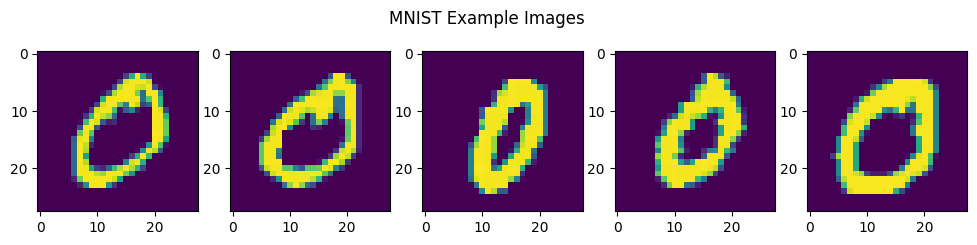

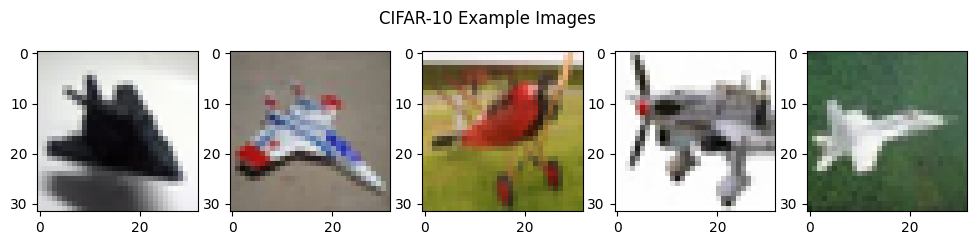

In [45]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
for i in range(5):
    ax[i].imshow(combined_dataset[i]['mnist_image'][0,:,:].numpy())
plt.show()

# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('CIFAR-10 Example Images')
for i in range(5):
    ax[i].imshow(np.transpose(combined_dataset[i]['cifar_image'].numpy(), (1,2,0)))
plt.show()



## Training Stitch

Train a stitch between the CIFAR-10 encoder and the MNIST decoder.

In [46]:
# define the loss function and the optimiser
criterion = nn.MSELoss()
optimiser = optim.SGD(cifar_to_mnist_model.parameters(), lr=1e-4, momentum=0.9, weight_decay=0.01)

stitch_train_epochs = 30
loss_history = []
for epoch in range(stitch_train_epochs):
    running_loss = 0.0
    for data in combined_loader:  
        
        # get data and put it on the GPU
        inputs, targets = data['cifar_image'], data['mnist_image']
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero the parameter gradients
        optimiser.zero_grad()

        # forward + loss + backward + optimise (update weights)
        outputs = cifar_to_mnist_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimiser.step()

        # keep track of the loss this epoch
        running_loss += loss.item()

    # Log training losses
    avg_loss = running_loss / len(combined_loader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{stitch_train_epochs}], Loss: {avg_loss:.6f}')

Epoch [1/30], Loss: 0.089811
Epoch [2/30], Loss: 0.087265
Epoch [3/30], Loss: 0.085112
Epoch [4/30], Loss: 0.083297
Epoch [5/30], Loss: 0.081795
Epoch [6/30], Loss: 0.080534
Epoch [7/30], Loss: 0.079492
Epoch [8/30], Loss: 0.078601
Epoch [9/30], Loss: 0.077854
Epoch [10/30], Loss: 0.077215
Epoch [11/30], Loss: 0.076644
Epoch [12/30], Loss: 0.076158
Epoch [13/30], Loss: 0.075722
Epoch [14/30], Loss: 0.075348
Epoch [15/30], Loss: 0.075015
Epoch [16/30], Loss: 0.074723
Epoch [17/30], Loss: 0.074481
Epoch [18/30], Loss: 0.074229
Epoch [19/30], Loss: 0.074032
Epoch [20/30], Loss: 0.073850
Epoch [21/30], Loss: 0.073692
Epoch [22/30], Loss: 0.073541
Epoch [23/30], Loss: 0.073394
Epoch [24/30], Loss: 0.073268
Epoch [25/30], Loss: 0.073151
Epoch [26/30], Loss: 0.073045
Epoch [27/30], Loss: 0.072940
Epoch [28/30], Loss: 0.072846
Epoch [29/30], Loss: 0.072760
Epoch [30/30], Loss: 0.072676


Text(0.5, 1.0, 'CIFAR-10 to MNIST Training Loss')

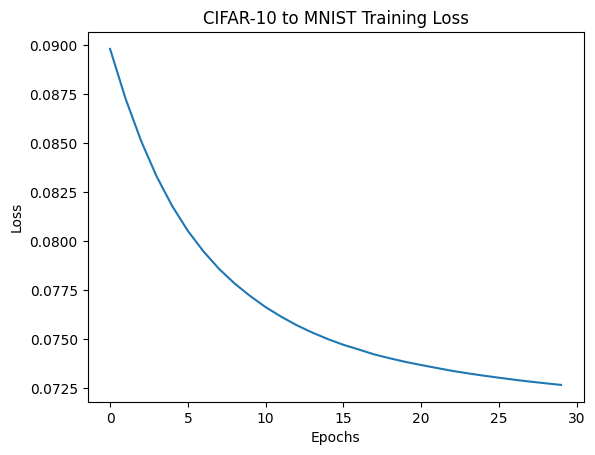

In [47]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-10 to MNIST Training Loss')

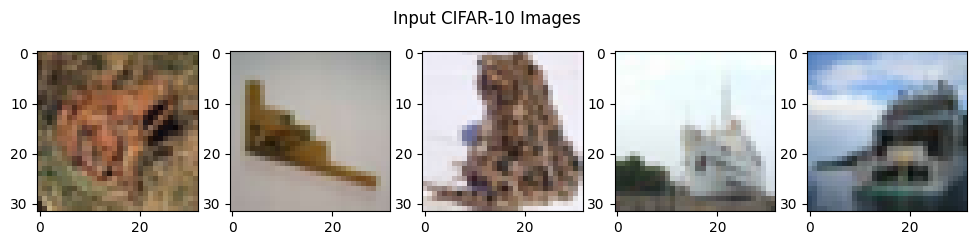

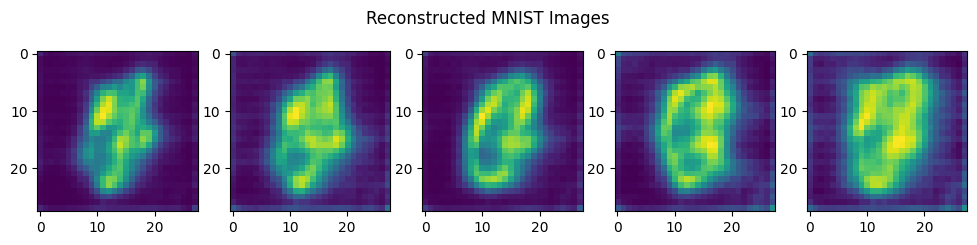

In [48]:
# Sample cifar-10 images
data = next(iter(combined_loader))
inputs, targets = data['cifar_image'], data['mnist_image']

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input CIFAR-10 Images')
ax[0].imshow(np.transpose(inputs[0].cpu().numpy(), (1,2,0)))
ax[1].imshow(np.transpose(inputs[1].cpu().numpy(), (1,2,0)))
ax[2].imshow(np.transpose(inputs[2].cpu().numpy(), (1,2,0)))
ax[3].imshow(np.transpose(inputs[3].cpu().numpy(), (1,2,0)))
ax[4].imshow(np.transpose(inputs[4].cpu().numpy(), (1,2,0)))
plt.show()

# Run images though the autoencdoer
output = cifar_to_mnist_model(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images')
ax[0].imshow(output[0,0,:,:].detach().cpu().numpy())
ax[1].imshow(output[1,0,:,:].detach().cpu().numpy())
ax[2].imshow(output[2,0,:,:].detach().cpu().numpy())
ax[3].imshow(output[3,0,:,:].detach().cpu().numpy())
ax[4].imshow(output[4,0,:,:].detach().cpu().numpy())
plt.show()

# Principle Component Analysis

Let's try to cluster bottleneck features in each autoencoder

In [ ]:
colors = {0:'red', 1:'orange', 2:'yellow', 3: 'yellowgreen', 4: 'lime', 5: 'cyan', 6: 'blue', 7: 'indigo', 8: 'plum', 9: 'black'}

In [ ]:
mnist_bottleneck_points = np.zeros((0, bottleneck_size))
mnist_labels = np.zeros(0)
for data in mnist_loader:
    # Sample data from dataset
    img, labels = data
    bn = mnist_model.encoder(img.to(device))
    mnist_bottleneck_points = np.concatenate([mnist_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    mnist_labels = np.concatenate([mnist_labels, labels.numpy()], axis=0)


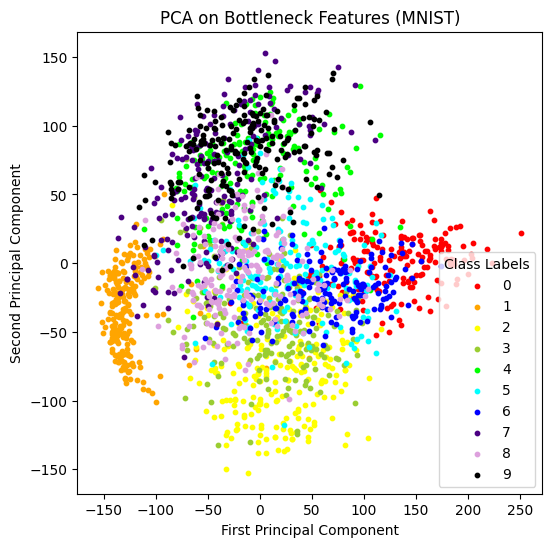

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
total_points = 2000
X_pca = pca.fit_transform(mnist_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (MNIST)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[mnist_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')

In [ ]:
cifar_bottleneck_points = np.zeros((0, bottleneck_size))
cifar_labels = np.zeros(0)
for data in cifar_loader:
    # Sample data from dataset
    img, labels = data
    bn = cifar_model.encoder(img.to(device))
    cifar_bottleneck_points = np.concatenate([cifar_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    cifar_labels = np.concatenate([cifar_labels, labels.numpy()], axis=0)


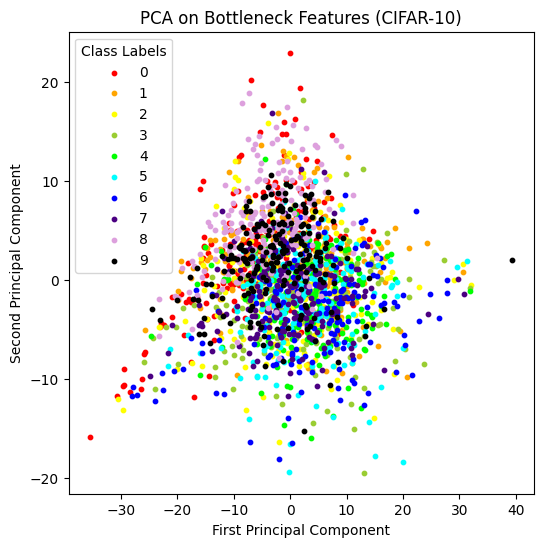

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cifar_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (CIFAR-10)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[cifar_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')